<a href="https://colab.research.google.com/github/macyso12/2D_Array_Menu/blob/main/NetflixMovie_TVShow_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# ----------------------------
# 1. INSTALL & IMPORT LIBRARIES
# ----------------------------
# Uncomment the line below if running in Google Colab
# !pip install wordcloud

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [25]:
# Style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")
NETFLIX_RED = '#E50914'
DARK_BG = '#141414'
LIGHT_GRAY = '#f5f5f5'

In [26]:
# ----------------------------
# 2. LOAD DATA
# ----------------------------
# If running in Google Colab, upload the file first or mount Drive
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv('netflix_titles.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nSample:\n{df.head(3)}")

Dataset shape: (8807, 12)

Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Missing values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Sample:
  show_id     type                 title         director  \
0      s1    Movie  Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show         Blood & Water              NaN   
2      s3  TV Show             Ganglands  Julien Leclercq   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   

   

In [27]:
# ----------------------------
# 3. DATA CLEANING
# ----------------------------
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format='%B %d, %Y', errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# Duration: split into movies (minutes) and shows (seasons)
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)

# Movies vs TV Shows breakdown

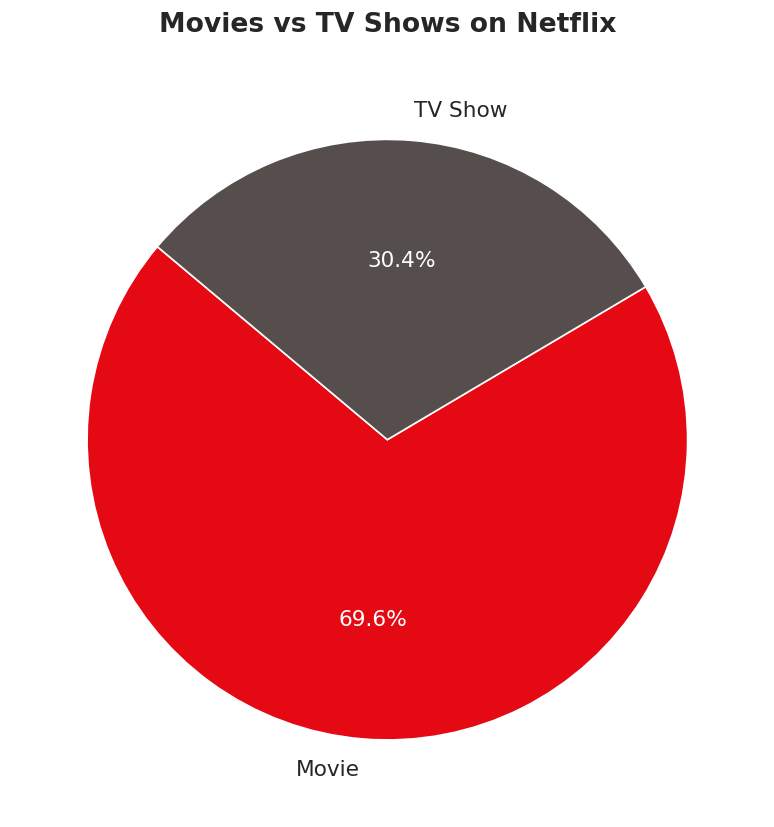

✅ Chart 1 saved: Movies vs TV Shows


In [28]:
# ----------------------------
# 4. MOVIES VS TV SHOWS
# ----------------------------
fig, ax = plt.subplots(figsize=(7, 7))
type_counts = df['type'].value_counts()
colors = [NETFLIX_RED, '#564d4d']
wedges, texts, autotexts = ax.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    textprops={'fontsize': 13}
)
for at in autotexts:
    at.set_color('white')
    at.set_fontsize(13)
ax.set_title('Movies vs TV Shows on Netflix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('1_movies_vs_tvshows.png', bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved: Movies vs TV Shows")

# Content added over time
Netflix's library grew year over year, great for spotting growth trends

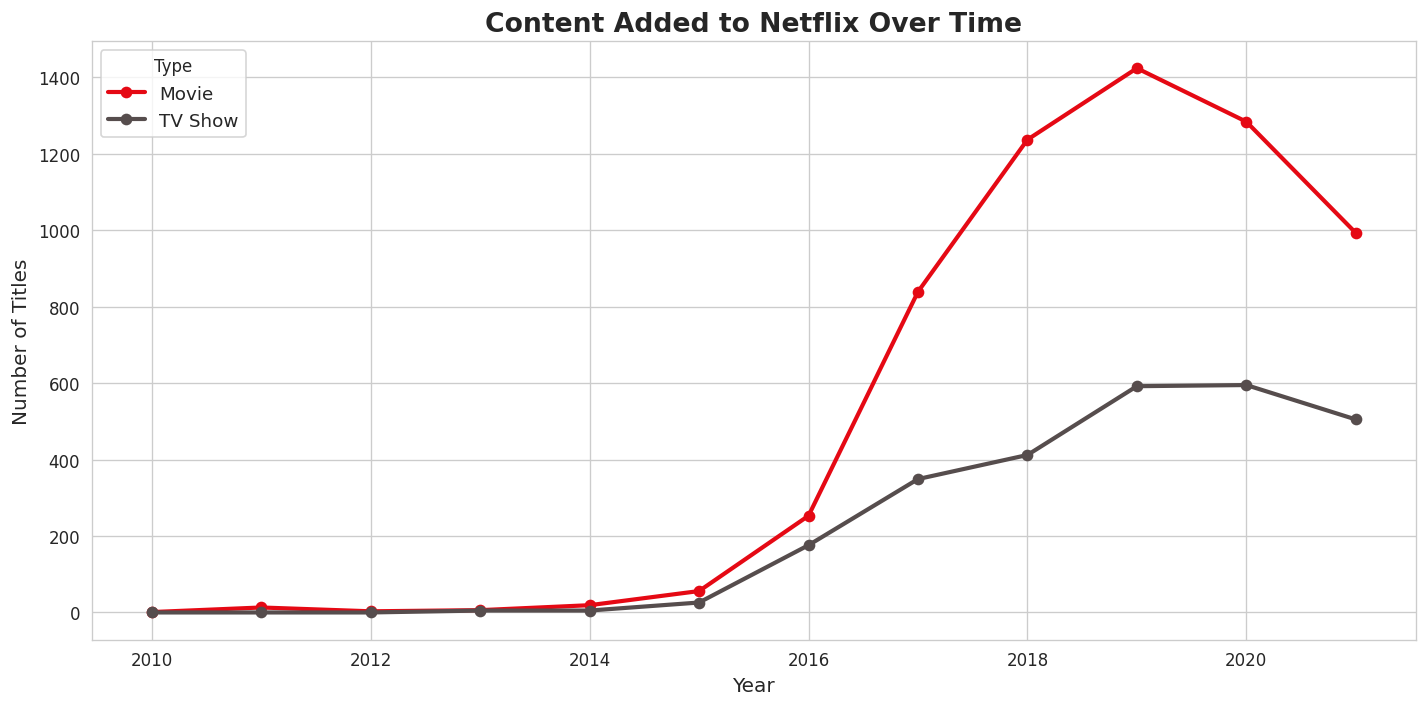

✅ Chart 2 saved: Content Added Over Time


In [29]:
# ----------------------------
# 5. CONTENT ADDED OVER TIME
# ----------------------------
yearly = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
yearly = yearly[yearly.index >= 2010]

fig, ax = plt.subplots(figsize=(12, 6))
yearly.plot(kind='line', ax=ax, marker='o', color=[NETFLIX_RED, '#564d4d'], linewidth=2.5)
ax.set_title('Content Added to Netflix Over Time', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Titles', fontsize=12)
ax.legend(title='Type', fontsize=11)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('2_content_over_time.png', bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved: Content Added Over Time")

# Top 10 countries producing content

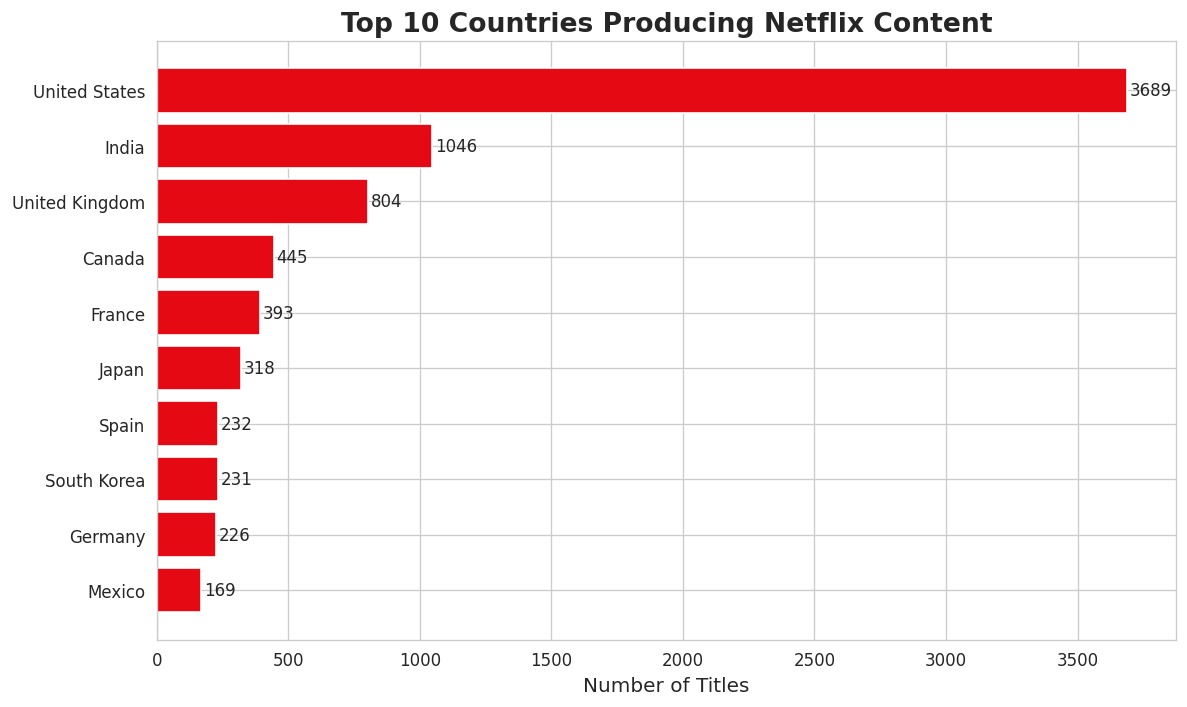

✅ Chart 3 saved: Top 10 Countries


In [30]:
# ----------------------------
# 6. TOP 10 COUNTRIES
# ----------------------------
country_series = df['country'].dropna().str.split(', ').explode()
top_countries = country_series.value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1], color=NETFLIX_RED)
ax.set_title('Top 10 Countries Producing Netflix Content', fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Titles', fontsize=12)
for bar, val in zip(bars, top_countries.values[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('3_top_countries.png', bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved: Top 10 Countries")

# Content ratings distribution
Bar chart of TV-MA, TV-14, PG-13 etc. — shows who Netflix targets most

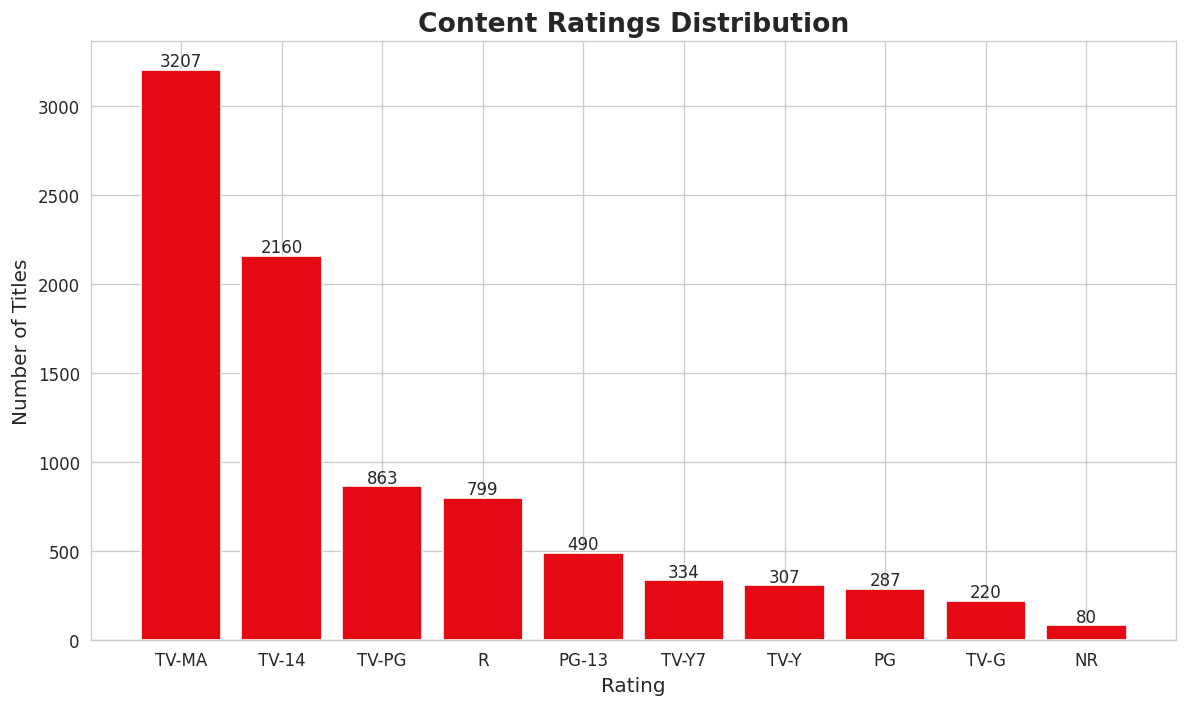

✅ Chart 4 saved: Ratings Distribution


In [31]:
# ----------------------------
# 7. CONTENT RATINGS DISTRIBUTION
# ----------------------------
rating_counts = df['rating'].value_counts().dropna().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(rating_counts.index, rating_counts.values, color=NETFLIX_RED, edgecolor='white')
ax.set_title('Content Ratings Distribution', fontsize=16, fontweight='bold')
ax.set_xlabel('Rating', fontsize=12)
ax.set_ylabel('Number of Titles', fontsize=12)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(int(bar.get_height())), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('4_ratings_distribution.png', bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved: Ratings Distribution")

# Top genres
Word cloud or bar chart of the most common genres across the catalog

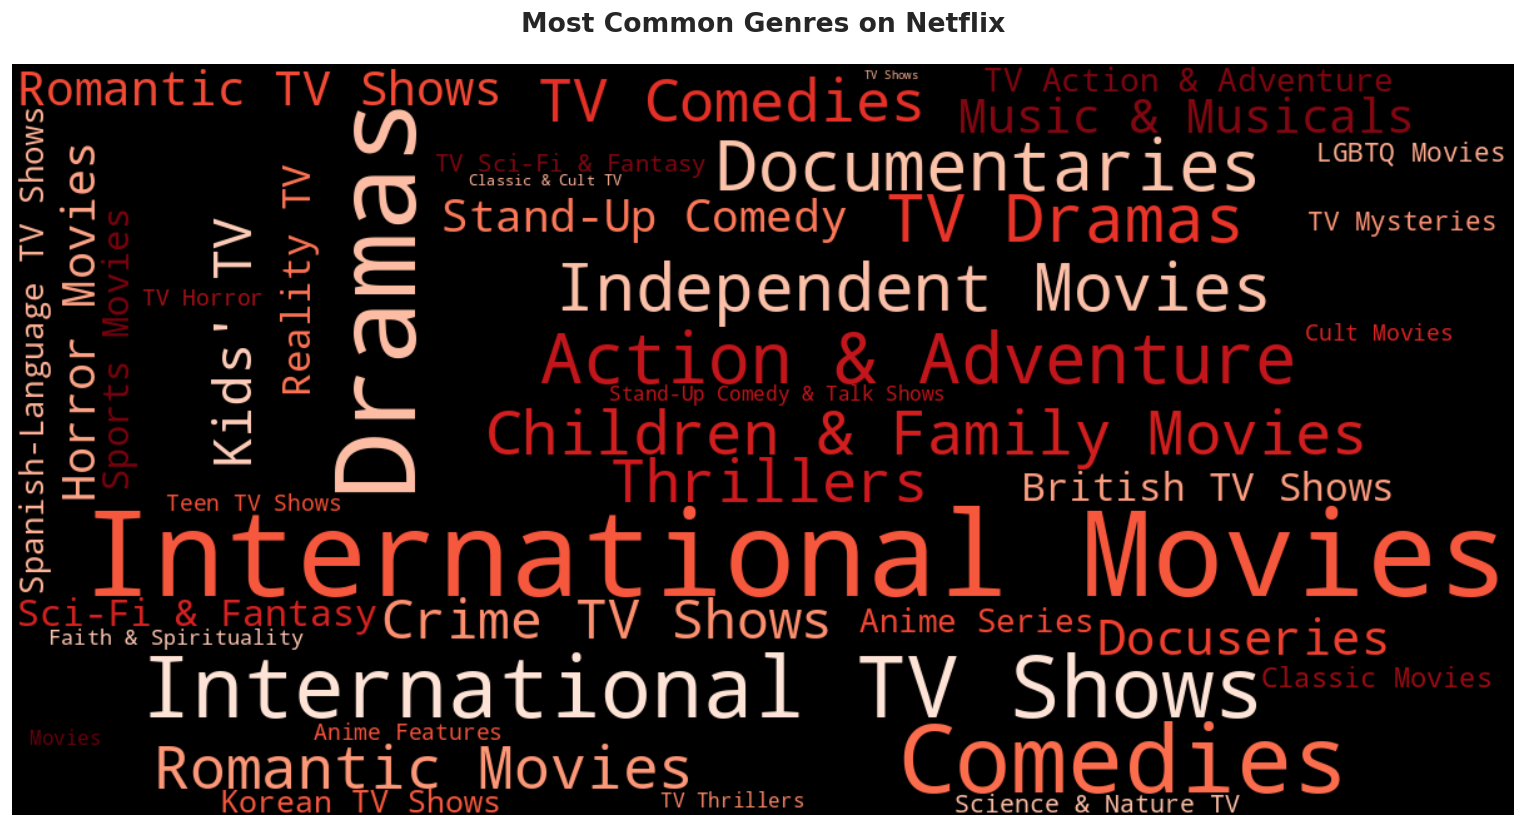

✅ Chart 5 saved: Genre Word Cloud


In [32]:
# ----------------------------
# 8. TOP GENRES (WORD CLOUD)
# ----------------------------
genres = df['listed_in'].dropna().str.split(', ').explode()
genre_counts = genres.value_counts()

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='black',
    colormap='Reds',
    max_words=80,
    prefer_horizontal=0.9
).generate_from_frequencies(genre_counts)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most Common Genres on Netflix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('5_genre_wordcloud.png', bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved: Genre Word Cloud")

# Top Genres

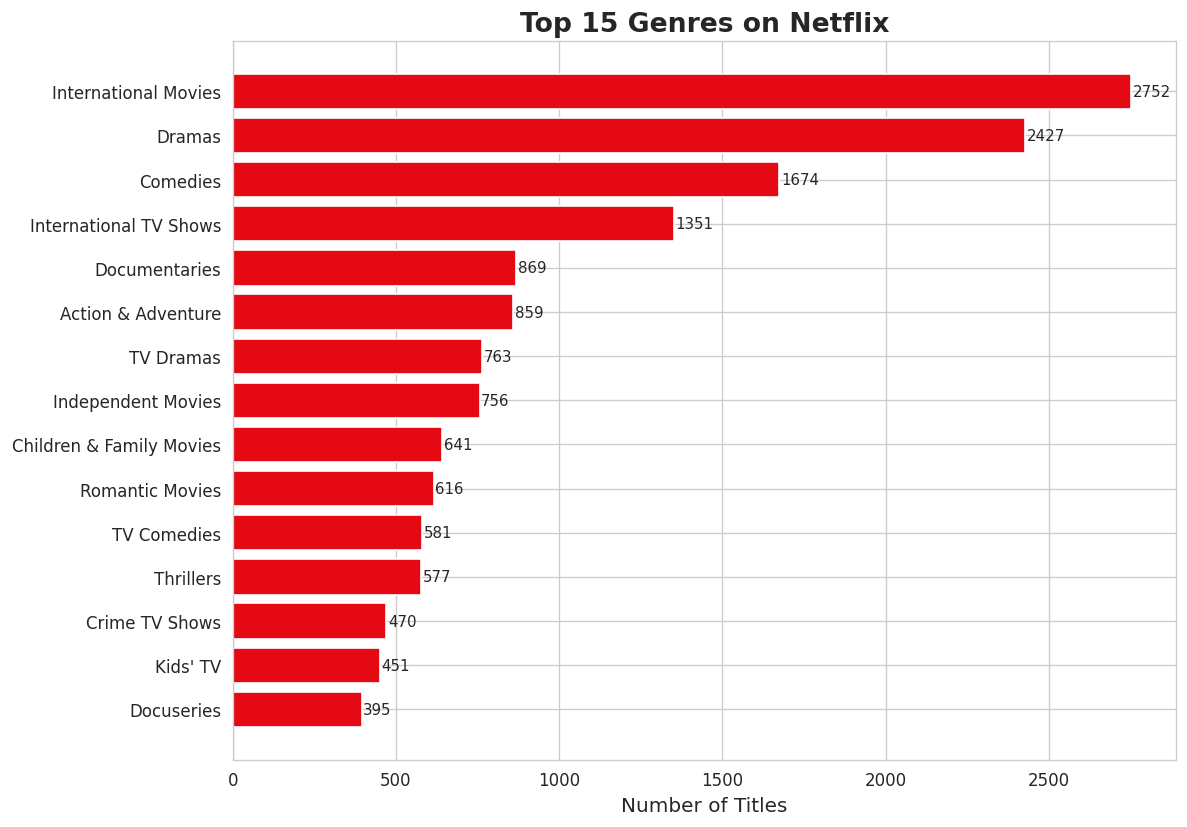

✅ Chart 6 saved: Top Genres Bar Chart


In [33]:
# ----------------------------
# 9. TOP GENRES BAR CHART
# ----------------------------
top_genres = genre_counts.head(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_genres.index[::-1], top_genres.values[::-1], color=NETFLIX_RED)
ax.set_title('Top 15 Genres on Netflix', fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Titles', fontsize=12)
for bar, val in zip(bars, top_genres.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('6_top_genres_bar.png', bbox_inches='tight')
plt.show()
print("✅ Chart 6 saved: Top Genres Bar Chart")

# Movie duration distribution
Histogram showing how long most Netflix movies are

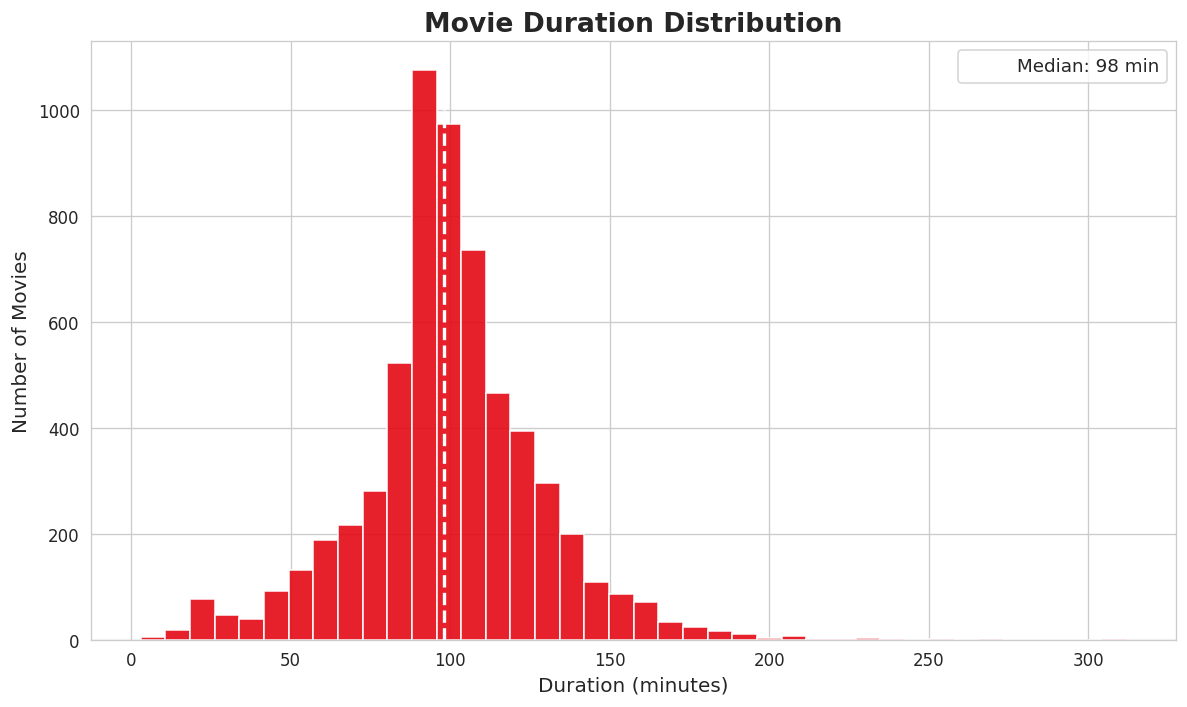

✅ Chart 7 saved: Movie Duration Distribution


In [34]:
# ----------------------------
# 10. MOVIE DURATION DISTRIBUTION
# ----------------------------
movies = df[df['type'] == 'Movie'].copy()

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(movies['duration_int'].dropna(), bins=40, color=NETFLIX_RED, edgecolor='white', alpha=0.9)
ax.axvline(movies['duration_int'].median(), color='white', linestyle='--', linewidth=2,
           label=f"Median: {int(movies['duration_int'].median())} min")
ax.set_title('Movie Duration Distribution', fontsize=16, fontweight='bold')
ax.set_xlabel('Duration (minutes)', fontsize=12)
ax.set_ylabel('Number of Movies', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('7_movie_duration.png', bbox_inches='tight')
plt.show()
print("✅ Chart 7 saved: Movie Duration Distribution")

# TV Show seasons distribution
How many shows have 1 season vs multi-season runs

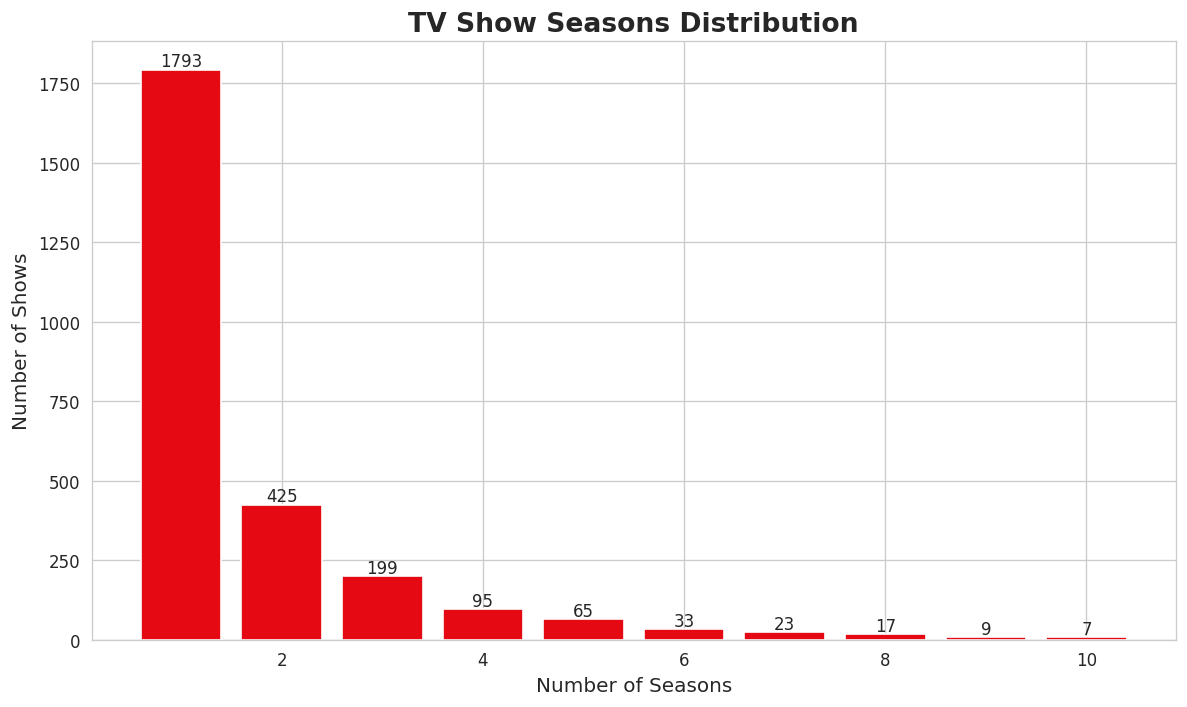

✅ Chart 8 saved: TV Show Seasons Distribution


In [35]:
# ----------------------------
# 11. TV SHOW SEASONS DISTRIBUTION
# ----------------------------
shows = df[df['type'] == 'TV Show'].copy()
season_counts = shows['duration_int'].dropna().value_counts().sort_index().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(season_counts.index.astype(int), season_counts.values, color=NETFLIX_RED, edgecolor='white')
ax.set_title('TV Show Seasons Distribution', fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Seasons', fontsize=12)
ax.set_ylabel('Number of Shows', fontsize=12)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(int(bar.get_height())), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('8_seasons_distribution.png', bbox_inches='tight')
plt.show()
print("✅ Chart 8 saved: TV Show Seasons Distribution")

# Content release year vs date added
Scatter plot showing how old content is when Netflix acquires it

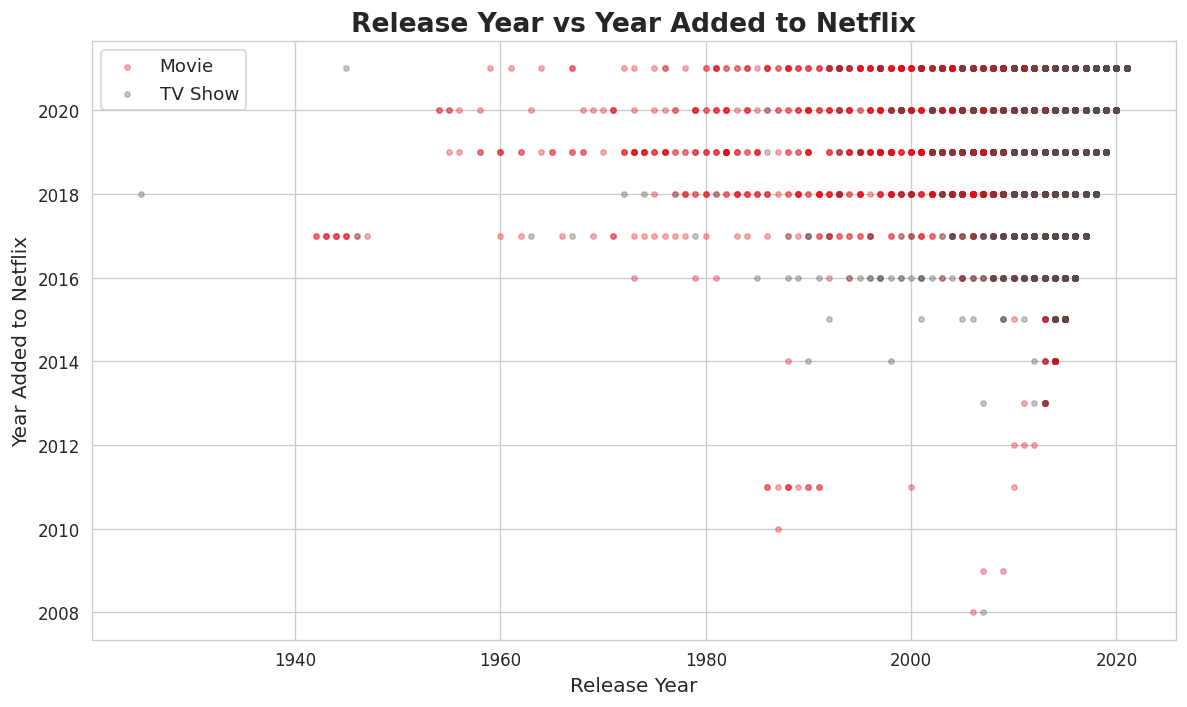

✅ Chart 9 saved: Release Year vs Year Added


In [36]:
# ----------------------------
# 12. RELEASE YEAR VS DATE ADDED (SCATTER)
# ----------------------------
scatter_df = df.dropna(subset=['year_added', 'release_year']).copy()
scatter_df['age_when_added'] = scatter_df['year_added'] - scatter_df['release_year']
scatter_df = scatter_df[scatter_df['age_when_added'] >= 0]

fig, ax = plt.subplots(figsize=(10, 6))
colors_map = {'Movie': NETFLIX_RED, 'TV Show': '#564d4d'}
for content_type, group in scatter_df.groupby('type'):
    ax.scatter(group['release_year'], group['year_added'],
               alpha=0.3, s=10, label=content_type,
               color=colors_map[content_type])
ax.set_title('Release Year vs Year Added to Netflix', fontsize=16, fontweight='bold')
ax.set_xlabel('Release Year', fontsize=12)
ax.set_ylabel('Year Added to Netflix', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('9_release_vs_added.png', bbox_inches='tight')
plt.show()
print("✅ Chart 9 saved: Release Year vs Year Added")

# Content growth by country over time
Which countries have grown their Netflix presence the most

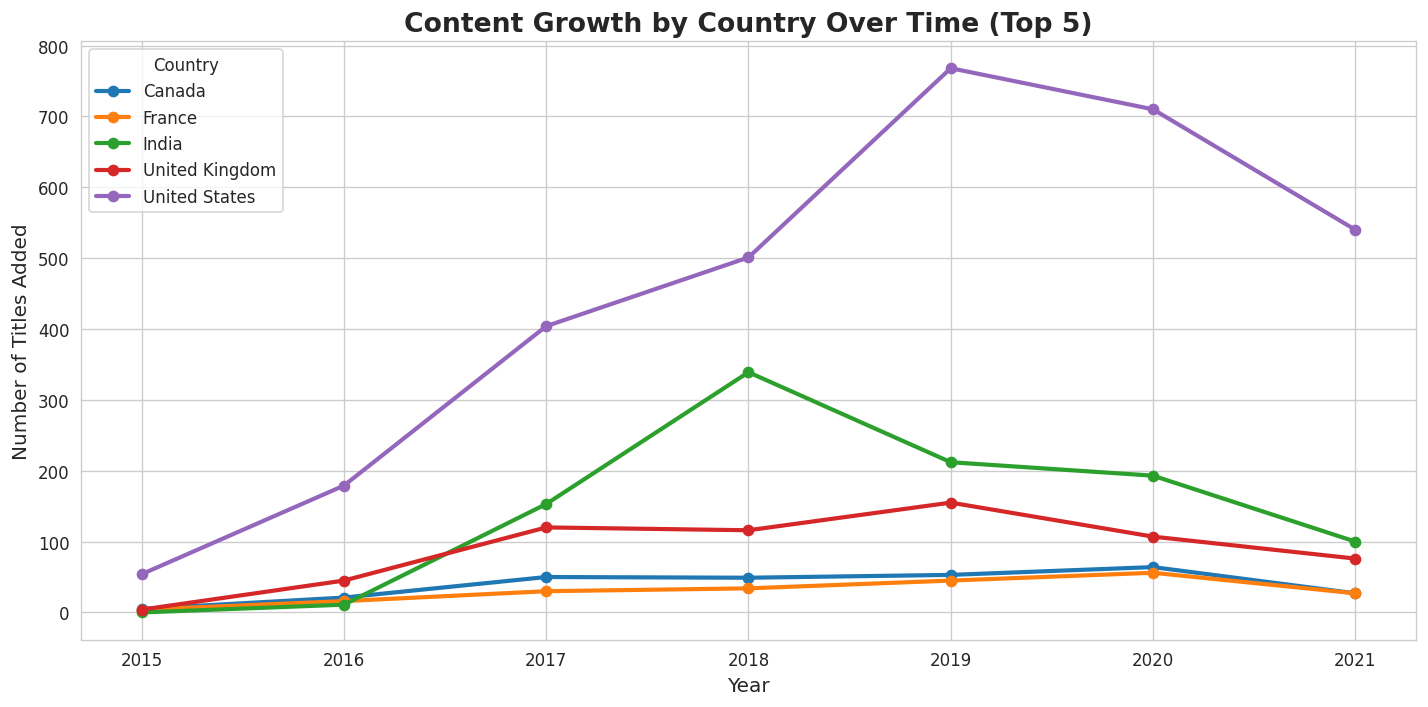

✅ Chart 10 saved: Content Growth by Country


In [37]:
# ----------------------------
# 13. CONTENT GROWTH BY COUNTRY OVER TIME
# ----------------------------
top5_countries = country_series.value_counts().head(5).index.tolist()
country_year = df.copy()
country_year['country_primary'] = df['country'].str.split(', ').str[0]
country_year_filtered = country_year[country_year['country_primary'].isin(top5_countries)]
country_growth = country_year_filtered.groupby(['year_added', 'country_primary']).size().unstack(fill_value=0)
country_growth = country_growth[country_growth.index >= 2015]

fig, ax = plt.subplots(figsize=(12, 6))
country_growth.plot(kind='line', ax=ax, marker='o', linewidth=2.5)
ax.set_title('Content Growth by Country Over Time (Top 5)', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Titles Added', fontsize=12)
ax.legend(title='Country', fontsize=10)
plt.tight_layout()
plt.savefig('10_country_growth.png', bbox_inches='tight')
plt.show()
print("✅ Chart 10 saved: Content Growth by Country")

# Genre trends over time
Are documentaries growing? Are comedies declining?

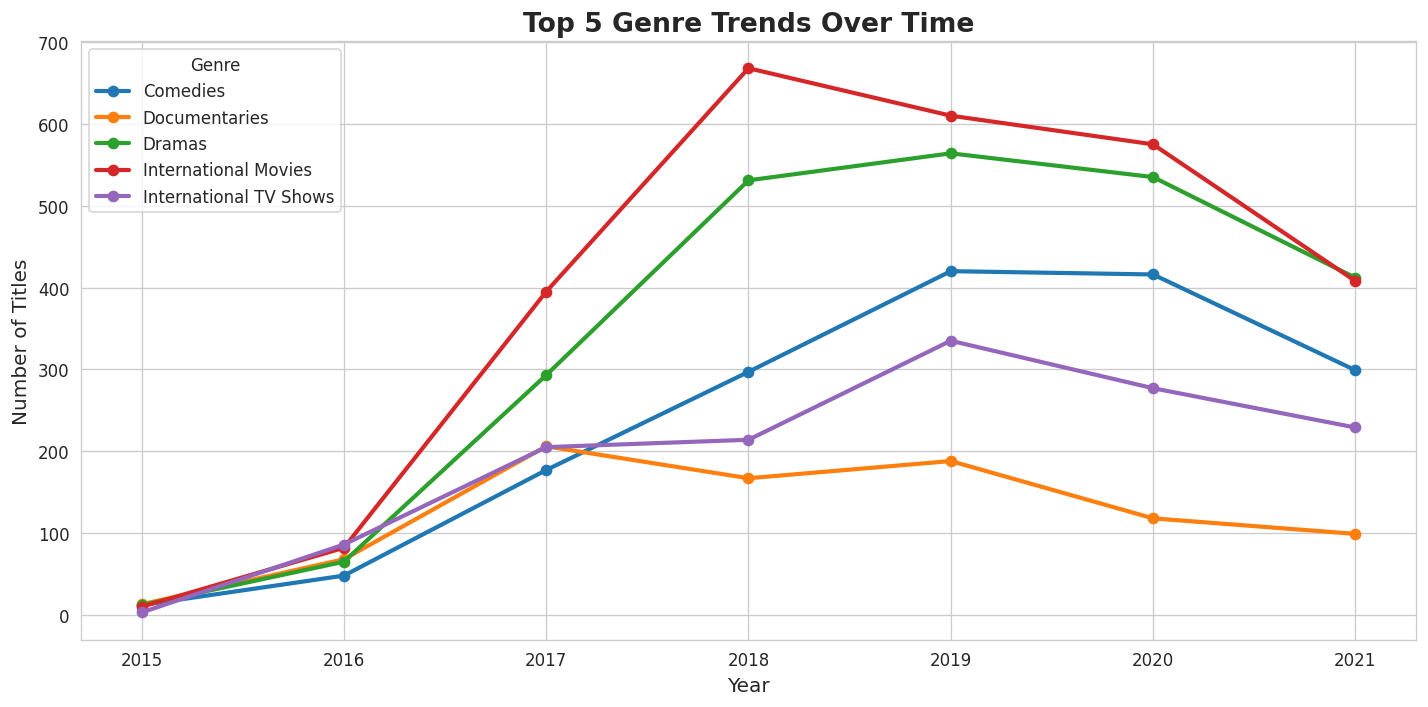

✅ Chart 11 saved: Genre Trends Over Time


In [38]:
# ----------------------------
# 14. GENRE TRENDS OVER TIME
# ----------------------------
top5_genres = genre_counts.head(5).index.tolist()
genre_year_df = df[['year_added', 'listed_in']].dropna()
genre_year_df = genre_year_df[genre_year_df['year_added'] >= 2015]
genre_year_df = genre_year_df.assign(genre=genre_year_df['listed_in'].str.split(', ')).explode('genre')
genre_year_filtered = genre_year_df[genre_year_df['genre'].isin(top5_genres)]
genre_trend = genre_year_filtered.groupby(['year_added', 'genre']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
genre_trend.plot(kind='line', ax=ax, marker='o', linewidth=2.5)
ax.set_title('Top 5 Genre Trends Over Time', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Titles', fontsize=12)
ax.legend(title='Genre', fontsize=10)
plt.tight_layout()
plt.savefig('11_genre_trends.png', bbox_inches='tight')
plt.show()
print("✅ Chart 11 saved: Genre Trends Over Time")

# Top directors and actors
Who appears most frequently across the catalog

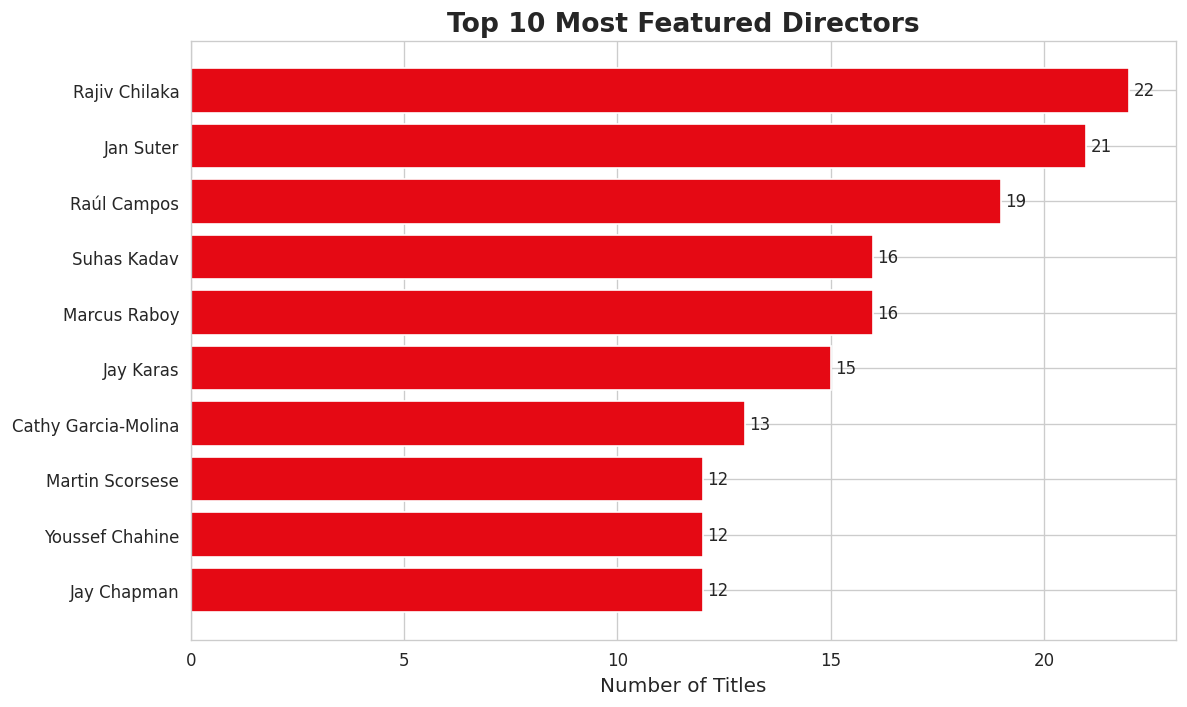

✅ Chart 12 saved: Top Directors


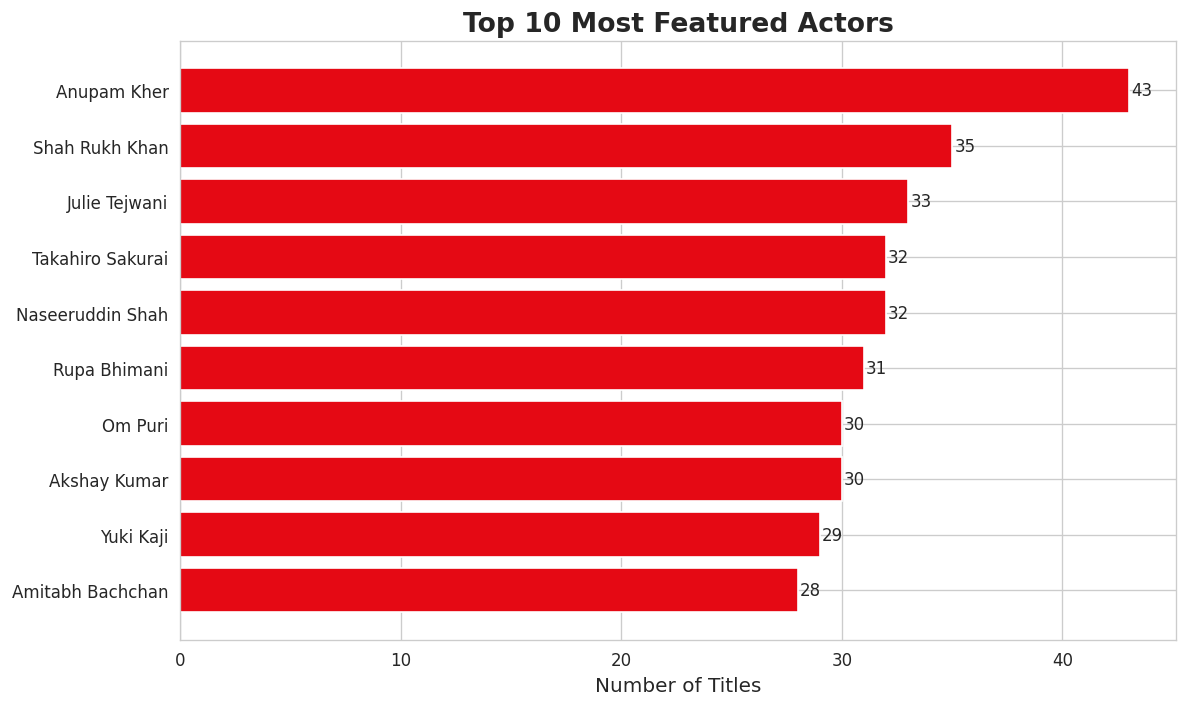

✅ Chart 13 saved: Top Actors


In [39]:
# ----------------------------
# 15. TOP DIRECTORS
# ----------------------------
directors = df['director'].dropna().str.split(', ').explode()
top_directors = directors.value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_directors.index[::-1], top_directors.values[::-1], color=NETFLIX_RED)
ax.set_title('Top 10 Most Featured Directors', fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Titles', fontsize=12)
for bar, val in zip(bars, top_directors.values[::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('12_top_directors.png', bbox_inches='tight')
plt.show()
print("✅ Chart 12 saved: Top Directors")


# ----------------------------
# 16. TOP ACTORS
# ----------------------------
actors = df['cast'].dropna().str.split(', ').explode()
top_actors = actors.value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_actors.index[::-1], top_actors.values[::-1], color=NETFLIX_RED)
ax.set_title('Top 10 Most Featured Actors', fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Titles', fontsize=12)
for bar, val in zip(bars, top_actors.values[::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('13_top_actors.png', bbox_inches='tight')
plt.show()
print("✅ Chart 13 saved: Top Actors")



In [41]:
# ----------------------------
# SUMMARY
# ----------------------------
print("\n" + "="*50)
print("ALL CHARTS GENERATED SUCCESSFULLY")
print("="*50)
print(f"\nKey Stats:")
print(f"Total titles: {len(df):,}")
print(f"Movies: {len(df[df['type']=='Movie']):,}")
print(f"TV Shows: {len(df[df['type']=='TV Show']):,}")
print(f"Countries represented: {country_series.nunique()}")
print(f"Unique genres: {genres.nunique()}")
print(f"Year range: {df['release_year'].min()} - {df['release_year'].max()}")


ALL CHARTS GENERATED SUCCESSFULLY

Key Stats:
Total titles: 8,807
Movies: 6,131
TV Shows: 2,676
Countries represented: 127
Unique genres: 42
Year range: 1925 - 2021
